In [ ]:
import json
import os
from getpass import getpass

from dotenv import load_dotenv
from haystack import Document, Pipeline
from haystack.components.builders import AnswerBuilder, PromptBuilder
from haystack.components.embedders import (
    SentenceTransformersDocumentEmbedder, SentenceTransformersTextEmbedder)
from haystack.components.generators import OpenAIGenerator
from haystack.components.preprocessors import DocumentCleaner, DocumentSplitter
from haystack.components.retrievers.in_memory import InMemoryEmbeddingRetriever
from haystack.components.writers import DocumentWriter
from haystack.document_stores.in_memory import InMemoryDocumentStore
from haystack.document_stores.types import DuplicatePolicy

from pydata_manchester_talk.utility import get_long_answer


In [ ]:
load_dotenv()

In [ ]:
NATURAL_QUESTIONS_FILE_PATH = "../data/subset_training_data.jsonl"
QUESTION_ANSWERING_PROMPT_TEMPLATE_FILE_PATH = "../prompts/question_answering_prompt.txt"

In [ ]:
with open(QUESTION_ANSWERING_PROMPT_TEMPLATE_FILE_PATH, 'r') as file:
    prompt_template = file.read()

In [ ]:
wiki_docs = []
with open(NATURAL_QUESTIONS_FILE_PATH, 'r') as file:
    for i, line in enumerate(file):
        wiki_docs.append(json.loads(line))

In [ ]:
first_10_docs = wiki_docs[0:10]

In [ ]:
example_wiki_document = first_10_docs[0].get("document_text")

In [ ]:
example_wiki_document

In [ ]:
document_store = InMemoryDocumentStore()

In [ ]:
docs_for_vector_db = [Document(content=doc["document_text"][0:1000]) for doc in first_10_docs]

In [ ]:
document_embedder = SentenceTransformersDocumentEmbedder(model="sentence-transformers/all-MiniLM-L6-v2")
document_writer = DocumentWriter(document_store=document_store, policy=DuplicatePolicy.SKIP)

In [ ]:
indexing = Pipeline()
indexing.add_component(instance=document_embedder, name="document_embedder")
indexing.add_component(instance=document_writer, name="document_writer")

indexing.connect("document_embedder.documents", "document_writer.documents")

indexing.run({"document_embedder": {"documents": docs_for_vector_db}})

In [ ]:
if "OPENAI_API_KEY" not in os.environ:
    os.environ["OPENAI_API_KEY"] = getpass("Enter OpenAI API key:")

In [ ]:
rag_pipeline = Pipeline()
rag_pipeline.add_component(
    "query_embedder", SentenceTransformersTextEmbedder(model="sentence-transformers/all-MiniLM-L6-v2")
)
rag_pipeline.add_component("retriever", InMemoryEmbeddingRetriever(document_store, top_k=3))
rag_pipeline.add_component("prompt_builder", PromptBuilder(template=prompt_template))
rag_pipeline.add_component("generator", OpenAIGenerator(model="gpt-3.5-turbo"))
rag_pipeline.add_component("answer_builder", AnswerBuilder())

rag_pipeline.connect("query_embedder", "retriever.query_embedding")
rag_pipeline.connect("retriever", "prompt_builder.documents")
rag_pipeline.connect("prompt_builder", "generator")
rag_pipeline.connect("generator.replies", "answer_builder.replies")
rag_pipeline.connect("generator.meta", "answer_builder.meta")
rag_pipeline.connect("retriever", "answer_builder.documents")

In [ ]:
rag_pipeline.draw("/Users/patrickcallery/dev/pydata-manchester-talk/notebooks/pipeline.png")

In [ ]:
first_10_docs[1]

In [ ]:
question = "how i.met your mother who is the mother'"

response = rag_pipeline.run(
    {
        "query_embedder": {"text": question},
        "prompt_builder": {"question": question},
        "answer_builder": {"query": question},
    }
)
print(response["answer_builder"]["answers"][0].data)

In [ ]:
print(response["answer_builder"])

### Evaluating the RAG

In [ ]:
from haystack.components.evaluators.document_mrr import DocumentMRREvaluator

To evaluate the RAG, need the question, the document content and the answer

In [ ]:
ground_truth_docs = [{"document_text": doc.get("document_text"), "question_text" : doc.get("question_text"), "answer": get_long_answer(doc)} for doc in first_10_docs]

In [ ]:
ground_truth_docs[1]

In [ ]:
ground_truth_answers = [d.get("answer") for d in ground_truth_docs]

In [ ]:
for a in ground_truth_answers:
    print(a)

In [ ]:
rag_answers = []
retrieved_docs = []
questions = [doc.get("question_text") for doc in ground_truth_docs]

for question in list(questions):
    response = rag_pipeline.run(
        {
            "query_embedder": {"text": question},
            "prompt_builder": {"question": question},
            "answer_builder": {"query": question},
        }
    )
    print(f"Question: {question}")
    print("Answer from pipeline:")
    print(response["answer_builder"]["answers"][0].data)
    print("\n-----------------------------------\n")

    rag_answers.append(response["answer_builder"]["answers"][0].data)
    retrieved_docs.append(response["answer_builder"]["answers"][0].documents)

In [ ]:
eval_pipeline = Pipeline()

In [ ]:
eval_pipeline.add_component("doc_mrr_evaluator", DocumentMRREvaluator())

In [ ]:
results = eval_pipeline.run(
    {
        "doc_mrr_evaluator": {
            "ground_truth_documents": list([d] for d in docs_for_vector_db),
            "retrieved_documents": retrieved_docs,
        }
    }
)

In [ ]:
results

### Document Mean Reciprocal Rank

- checks at what rank ground truth labels appear in the list of retrieved docs
- example - say the RAG returns back 3 docs in a list of docs, where does the ground truth doc appear in the 
- questions - how does this work with chunking?

[Example](https://en.wikipedia.org/wiki/Mean_reciprocal_rank) of mean reciprocal rank from wiki

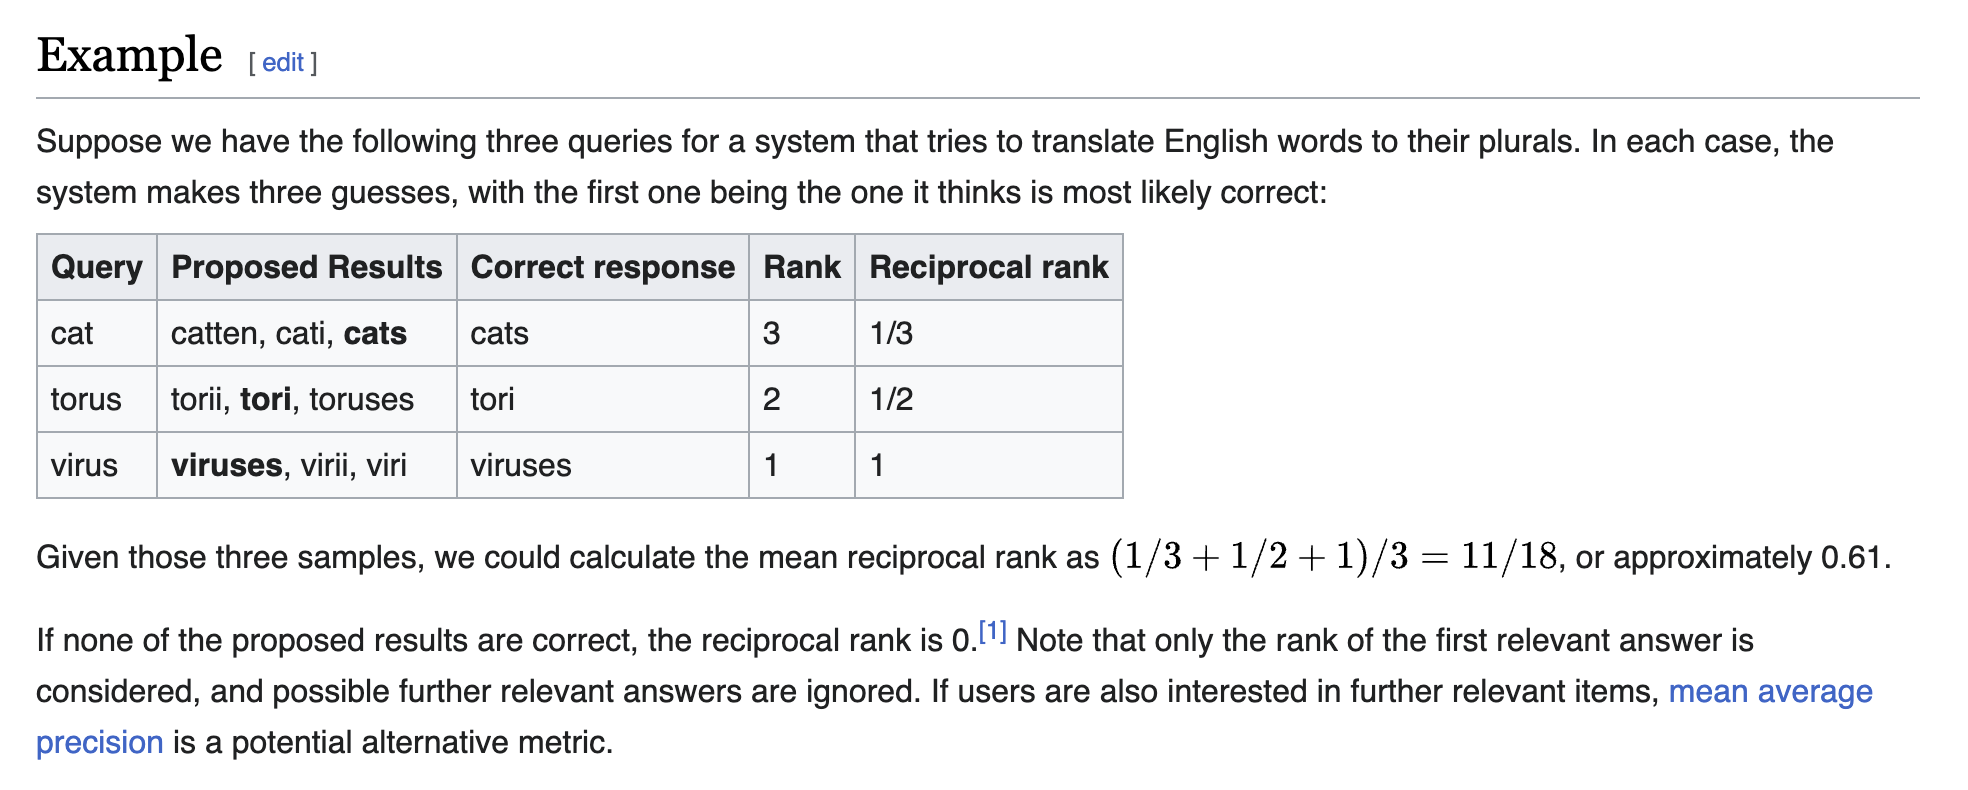

In [ ]:
from haystack.evaluation.eval_run_result import EvaluationRunResult

In [ ]:
inputs = {
    "question": list(questions),
    "contexts": list([d.content] for d in docs_for_vector_db),
    "answer": list(ground_truth_answers),
    "predicted_answer": rag_answers,
}

evaluation_result = EvaluationRunResult(run_name="pubmed_rag_pipeline", inputs=inputs, results=results)
evaluation_result.score_report()

In [ ]:
docs_for_vector_db

In [ ]:
retrieved_docs

In [ ]:
for a in ground_truth_answers:
    print(a)
    print("\n\n")